# Time Series — Moving Average Smoothing

- Moving Average: smooths out short-term noise by averaging over a sliding window of past values
- SMA: equal weight to all points in window; EMA: more weight to recent points
- Dataset: AirPassengers.csv (monthly airline passengers 1949-1960)[https://www.kaggle.com/datasets/rakannimer/air-passengers](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [3]:
df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month")

print(df.head())
print("Shape:", df.shape)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
Shape: (144, 1)


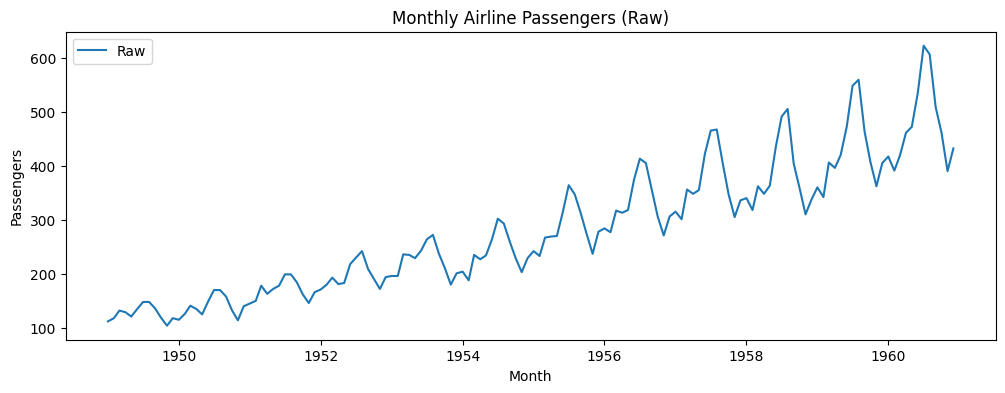

In [4]:
# Plot raw data
plt.figure(figsize=(12, 4))
plt.plot(df["Passengers"], label="Raw")
plt.title("Monthly Airline Passengers (Raw)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

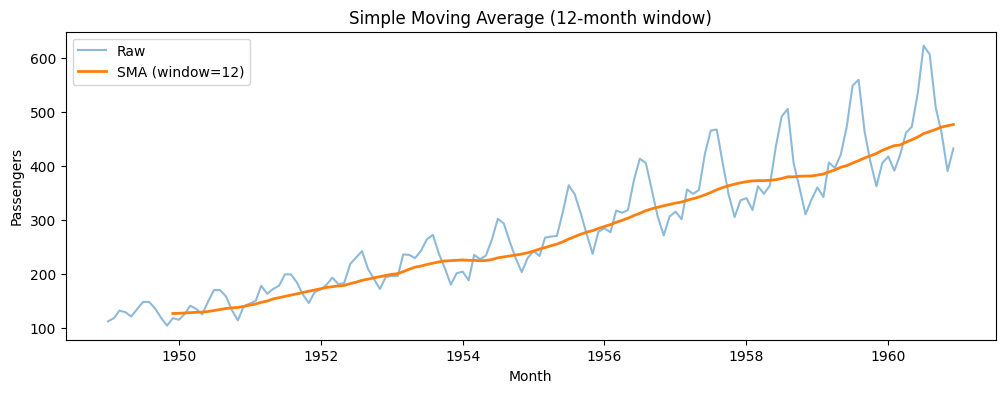

In [5]:
# Simple Moving Average

df["SMA_12"] = df["Passengers"].rolling(window=12).mean()

plt.figure(figsize=(12, 4))
plt.plot(df["Passengers"], label="Raw", alpha=0.5)
plt.plot(df["SMA_12"], label="SMA (window=12)", linewidth=2)
plt.title("Simple Moving Average (12-month window)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

rolling(window=12).mean() computes the 12-month SMA at each point — equal weight to all 12 months in the window
Window of 12 chosen to match the seasonal cycle (1 year) so seasonal peaks average out, leaving only the trend

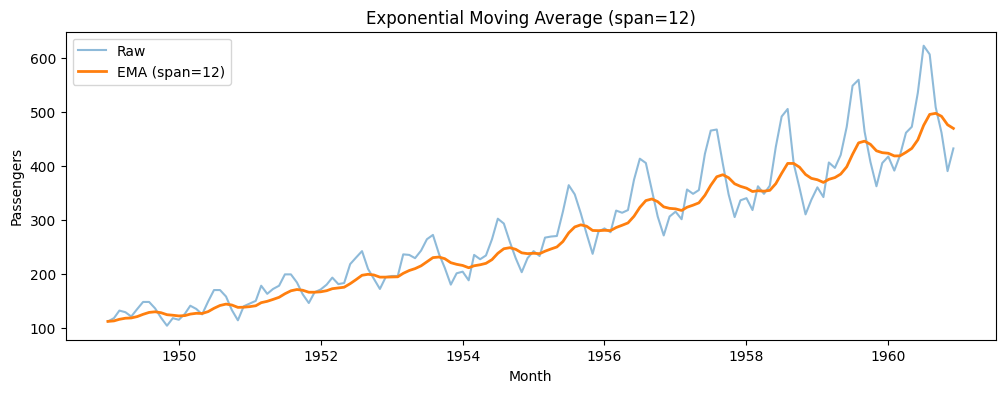

In [6]:
# Exponential Moving Average

df["EMA_12"] = df["Passengers"].ewm(span=12, adjust=False).mean()

plt.figure(figsize=(12, 4))
plt.plot(df["Passengers"], label="Raw", alpha=0.5)
plt.plot(df["EMA_12"], label="EMA (span=12)", linewidth=2)
plt.title("Exponential Moving Average (span=12)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

ewm(span=12) computes EMA with α = 2/(12+1) ≈ 0.154 — gives more weight to recent months
EMA tracks recent changes slightly faster than SMA

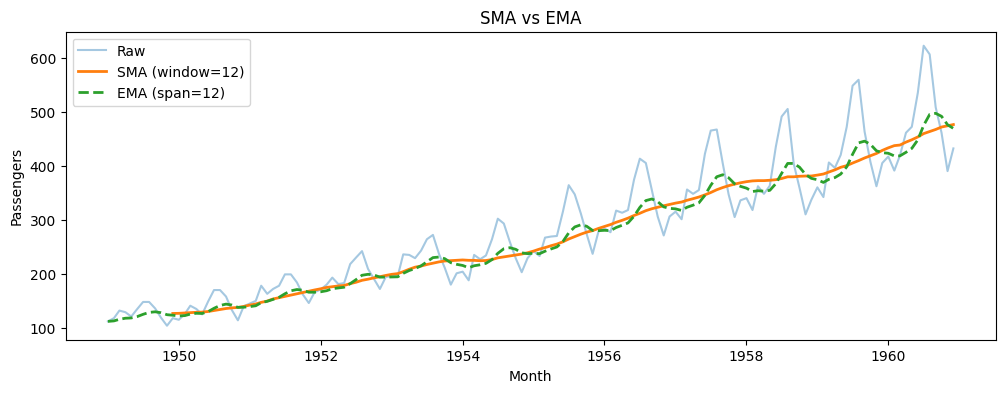

In [7]:
# SMA vs EMA comparison
plt.figure(figsize=(12, 4))
plt.plot(df["Passengers"], label="Raw", alpha=0.4)
plt.plot(df["SMA_12"], label="SMA (window=12)", linewidth=2)
plt.plot(df["EMA_12"], label="EMA (span=12)", linewidth=2, linestyle="--")
plt.title("SMA vs EMA")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

## Conclusion
- SMA averaged every 12-month window equally — completely smoothed out seasonal peaks, revealing the pure long-term trend
- EMA gave more weight to recent months — tracked the trend faster but retained slightly more of the seasonal variation
- Both clearly show the upward trend in airline passengers from 1949-1960 that was hidden under seasonal noise
- Moving Average is a smoothing/visualization tool, not a forecasting model — ARIMA and similar models use these concepts to actually predict future values